# Per-molecule radial power spectra in the TomoTwin tomogram

This experiment extracts a centered subtomogram for every ground-truth molecule, using that class's voxel diameter as the crop size. It computes a windowed 3-D periodogram for every instance, averages the radial PSDs (RPSDs) within each molecule class, estimates a matched background spectrum, and compares all classes on a common frequency grid.

Averaging reduces periodogram variance, but it does **not** remove the additive noise floor. For that reason the notebook shows both the observed class-mean RPSD and a background-subtracted estimate. The latter is clipped at zero and should be interpreted as an exploratory clean-signal estimate.

## Configuration

`particle_positions.txt` stores centers as `(x, y, z)` while MRC arrays use `(z, y, x)`. The diameter table is deliberately explicit. If `data/tomotwin_2df7/molecule_diameters.csv` exists with columns `class,diameter_voxels`, it overrides the baseline values below.

The current local dataset only establishes a 33-voxel usable TomoTwin crop (the network input is 37³), so 33 is used as a runnable baseline for every class. Replace these values with the measured per-molecule GT diameters before treating size-dependent conclusions as final.

In [1]:
from pathlib import Path
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
try:
    import mrcfile
except ImportError:
    mrcfile = None
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

from kltpicker_3d.alt_least_squares import alternating_least_squares_solver
from kltpicker_3d.spectral_estimation import estimate_isotropic_powerspectrum_tensor
from kltpicker_3d.tomogram import KLTParticleDetector3D
from kltpicker_3d.utils import (
    bandpass_filter_3d,
    calibrate_radial_psds,
    prewhiten_tomogram,
    radial_average_jax,
)

jax.config.update("jax_platform_name", "cpu")

DATA_DIR = Path("data/tomotwin_2df7")
TOMOGRAM_PATH = DATA_DIR / "tiltseries_rec.mrc"
POSITIONS_PATH = DATA_DIR / "particle_positions.txt"
DIAMETER_TABLE_PATH = DATA_DIR / "molecule_diameters.csv"

MOLECULE_CLASSES = ["1avo", "1e9r", "1fpy", "1fzg", "1jz8", "1oao", "2df7"]
DIAMETER_VOXELS = {name: 33 for name in MOLECULE_CLASSES}

N_RADIAL_BINS = 64
N_BACKGROUND_PER_CLASS = 100
RANDOM_SEED = 7
WINDOW = "hann"  # use None for an unwindowed periodogram

assert TOMOGRAM_PATH.exists(), TOMOGRAM_PATH
assert POSITIONS_PATH.exists(), POSITIONS_PATH

if DIAMETER_TABLE_PATH.exists():
    diameter_table = pd.read_csv(DIAMETER_TABLE_PATH)
    required = {"class", "diameter_voxels"}
    assert required <= set(diameter_table.columns), f"Required columns: {required}"
    DIAMETER_VOXELS.update(
        diameter_table.set_index("class")["diameter_voxels"].astype(float).to_dict()
    )

display(pd.Series(DIAMETER_VOXELS, name="diameter_voxels").to_frame())

,diameter_voxels
1avo,33
1e9r,33
1fpy,33
1fzg,33
1jz8,33
1oao,33
2df7,33


## Load the reconstruction and ground-truth centers

In [2]:
def load_mrc(path):
    """Load common MRC modes, with no hard dependency on mrcfile."""
    if mrcfile is not None:
        with mrcfile.open(path, permissive=True) as mrc:
            data = np.asarray(mrc.data, dtype=np.float32).copy()
            voxel_size = np.array([
                float(mrc.voxel_size.x), float(mrc.voxel_size.y), float(mrc.voxel_size.z)
            ])
        return data, voxel_size

    import struct
    with open(path, "rb") as stream:
        header = stream.read(1024)
        nx, ny, nz, mode = struct.unpack_from("<4i", header, 0)
        mx, my, mz = struct.unpack_from("<3i", header, 28)
        cella = np.array(struct.unpack_from("<3f", header, 40), dtype=float)
        nsymbt = struct.unpack_from("<i", header, 92)[0]
        dtype = {0: np.int8, 1: np.dtype("<i2"), 2: np.dtype("<f4"), 6: np.dtype("<u2")}.get(mode)
        if dtype is None:
            raise ValueError(f"Unsupported MRC mode {mode}")
        stream.seek(1024 + nsymbt)
        data = np.fromfile(stream, dtype=dtype, count=nx * ny * nz).reshape(nz, ny, nx)
    grid = np.array([mx, my, mz], dtype=float)
    voxel_size = np.divide(cella, grid, out=np.zeros(3), where=grid > 0)
    return data.astype(np.float32, copy=False), voxel_size

tomogram, voxel_size_xyz = load_mrc(TOMOGRAM_PATH)

columns = ["class", "x", "y", "z", "rot1", "rot2", "rot3"]
positions = pd.read_csv(POSITIONS_PATH, names=columns)
positions["class"] = positions["class"].str.lower()
positions[["z", "y", "x"]] = positions[["z", "y", "x"]].astype(float)

molecules = positions[positions["class"].isin(MOLECULE_CLASSES)].copy()
all_gt_zyx = positions[["z", "y", "x"]].to_numpy(float)

print("Tomogram shape (z, y, x):", tomogram.shape)
print("Voxel size (x, y, z):", voxel_size_xyz)
display(molecules.groupby("class").size().rename("GT instances").to_frame())

Tomogram shape (z, y, x): (200, 512, 512)
Voxel size (x, y, z): [10.20408154 10.20408154 10.20408154]


,GT instances
class,
1avo,91
1e9r,93
1fpy,97
1fzg,93
1jz8,91
1oao,94
2df7,100


## Extraction and RPSD helpers

Each diameter is rounded up to the nearest odd box side so a GT coordinate has one unambiguous center voxel. A separable Hann window suppresses crop-edge leakage. Frequencies are reported in cycles/voxel on the common inscribed Nyquist sphere, $0 \leq f \leq 0.5$.

In [3]:
radial_edges = np.linspace(0.0, 0.5, N_RADIAL_BINS + 1)
radial_frequency = 0.5 * (radial_edges[:-1] + radial_edges[1:])

def odd_box_side(diameter_voxels):
    side = int(np.ceil(float(diameter_voxels)))
    return side if side % 2 else side + 1

def extract_centered_cube(volume, center_zyx, side):
    center = np.rint(center_zyx).astype(int)
    half = side // 2
    start = center - half
    stop = center + half + 1
    if np.any(start < 0) or np.any(stop > np.asarray(volume.shape)):
        return None
    return volume[tuple(slice(a, b) for a, b in zip(start, stop))].copy()

def radial_periodogram(cube, edges=radial_edges, window=WINDOW):
    x = np.asarray(cube, dtype=np.float64)
    x = x - x.mean()
    if window == "hann":
        w1 = np.hanning(x.shape[0])
        w = w1[:, None, None] * w1[None, :, None] * w1[None, None, :]
        window_energy = np.mean(w**2)
        x = x * w
    elif window is None:
        window_energy = 1.0
    else:
        raise ValueError(f"Unknown window: {window}")

    power = np.abs(np.fft.fftn(x))**2 / (x.size * window_energy)
    f = np.fft.fftfreq(x.shape[0])
    fz, fy, fx = np.meshgrid(f, f, f, indexing="ij")
    radius = np.sqrt(fz**2 + fy**2 + fx**2)
    valid = radius <= edges[-1]
    shell = np.digitize(radius[valid], edges, right=False) - 1
    shell = np.clip(shell, 0, len(edges) - 2)
    sums = np.bincount(shell, weights=power[valid], minlength=len(edges) - 1)
    counts = np.bincount(shell, minlength=len(edges) - 1)
    averages = np.divide(
        sums, counts, out=np.full_like(sums, np.nan, dtype=float), where=counts > 0
    )
    # Small crops sample Fourier space sparsely. Interpolate genuinely empty
    # radial shells instead of treating them as zero power; otherwise classes
    # with different crop diameters acquire artificial spectral differences.
    bin_centers = 0.5 * (edges[:-1] + edges[1:])
    sampled = np.isfinite(averages)
    if sampled.sum() < 2:
        raise ValueError("Too few populated radial shells; reduce N_RADIAL_BINS")
    return np.interp(bin_centers, bin_centers[sampled], averages[sampled])

def extract_valid_cubes(volume, centers_zyx, side):
    cubes, kept_centers = [], []
    for center in np.asarray(centers_zyx):
        cube = extract_centered_cube(volume, center, side)
        if cube is not None:
            cubes.append(cube)
            kept_centers.append(center)
    return cubes, np.asarray(kept_centers)

def sample_background_centers(shape, side, n, forbidden_zyx, exclusion_radius, rng):
    half = side // 2
    low = np.full(3, half)
    high = np.asarray(shape) - half
    accepted = []
    max_attempts = 200 * n
    for _ in range(max_attempts):
        center = np.array([rng.integers(a, b) for a, b in zip(low, high)])
        if np.min(np.linalg.norm(forbidden_zyx - center, axis=1)) < exclusion_radius:
            continue
        if accepted and np.min(np.linalg.norm(np.asarray(accepted) - center, axis=1)) < side:
            continue
        accepted.append(center)
        if len(accepted) == n:
            break
    if len(accepted) < n:
        print(f"Warning: requested {n} background boxes, found {len(accepted)}")
    return np.asarray(accepted)

def normalize_rpsd_shape(rpsd):
    # Normalize by the isotropic 3-D power integral, proportional to 4*pi*f^2 df.
    weights = 4 * np.pi * radial_frequency**2
    total = np.trapezoid(weights * rpsd, radial_frequency)
    return rpsd / total if total > 0 else np.zeros_like(rpsd)

## Compute per-instance and per-molecule RPSDs

Background boxes are matched to each class's crop diameter and kept away from every annotated object, including vesicles and fiducials. `observed_mean` is the direct average requested; `signal_mean` subtracts the matched mean background RPSD.

In [4]:
rng = np.random.default_rng(RANDOM_SEED)
results = {}

for molecule in MOLECULE_CLASSES:
    diameter = float(DIAMETER_VOXELS[molecule])
    side = odd_box_side(diameter)
    centers = molecules.loc[molecules["class"] == molecule, ["z", "y", "x"]].to_numpy()
    cubes, kept_centers = extract_valid_cubes(tomogram, centers, side)
    if not cubes:
        print(f"Skipping {molecule}: no in-bounds crops")
        continue

    instance_rpsds = np.stack([radial_periodogram(cube) for cube in cubes])
    n_background = min(N_BACKGROUND_PER_CLASS, len(cubes))
    background_centers = sample_background_centers(
        tomogram.shape, side, n_background, all_gt_zyx,
        exclusion_radius=side, rng=rng,
    )
    background_cubes, _ = extract_valid_cubes(tomogram, background_centers, side)
    background_rpsds = np.stack([radial_periodogram(cube) for cube in background_cubes])

    observed_mean = instance_rpsds.mean(axis=0)
    background_mean = background_rpsds.mean(axis=0)
    signal_mean = np.maximum(observed_mean - background_mean, 0.0)
    results[molecule] = {
        "diameter": diameter,
        "side": side,
        "cubes": cubes,
        "centers": kept_centers,
        "instance_rpsds": instance_rpsds,
        "background_rpsds": background_rpsds,
        "observed_mean": observed_mean,
        "background_mean": background_mean,
        "signal_mean": signal_mean,
        "signal_shape": normalize_rpsd_shape(signal_mean),
    }

summary = pd.DataFrame([
    {
        "class": name,
        "diameter_voxels": value["diameter"],
        "crop_side": value["side"],
        "instances_used": len(value["cubes"]),
        "background_boxes": len(value["background_rpsds"]),
        "observed_variance": np.mean([np.var(cube) for cube in value["cubes"]]),
        "signal_rpsd_integral": np.trapezoid(
            4 * np.pi * radial_frequency**2 * value["signal_mean"], radial_frequency
        ),
    }
    for name, value in results.items()
]).set_index("class")
display(summary.round(5))

,diameter_voxels,crop_side,instances_used,background_boxes,observed_variance,signal_rpsd_integral
class,,,,,,
1avo,33.0,33,91,91,4934.311523,1072.53633
1e9r,33.0,33,93,93,4862.272461,1132.49152
1fpy,33.0,33,97,97,4892.348633,2178.95477
1fzg,33.0,33,93,93,4812.301270,1052.57911
1jz8,33.0,33,91,91,4924.416992,2133.45121
1oao,33.0,33,94,94,4870.133789,1507.78624
2df7,33.0,33,100,100,5290.620605,2167.79349


## Centering sanity check

The mean subtomogram is only a centering diagnostic: molecules have arbitrary rotations, so structural detail is expected to blur.

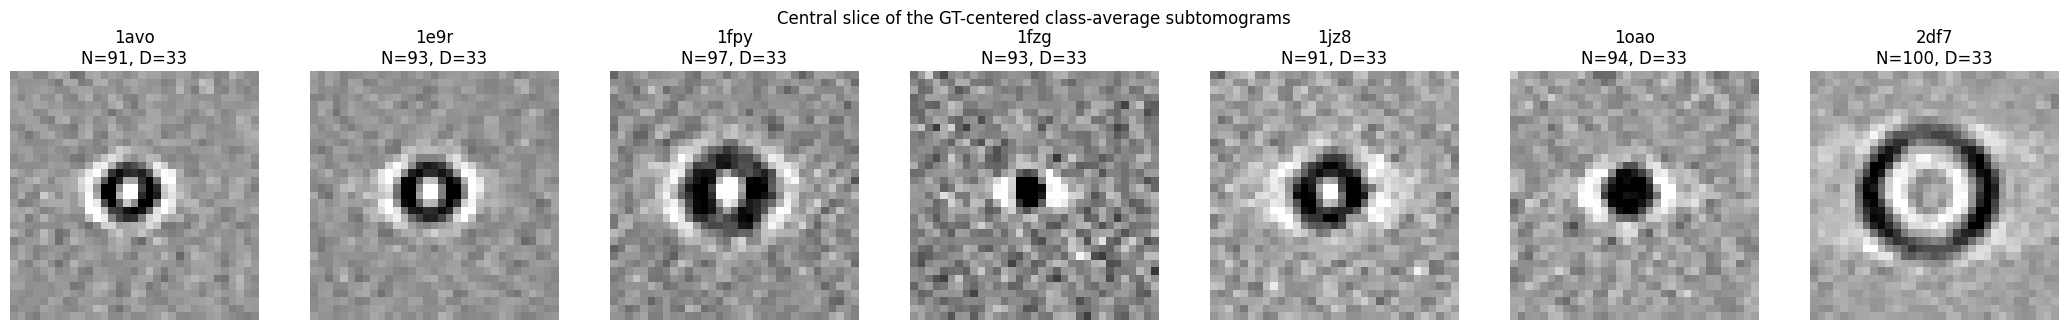

In [5]:
fig, axes = plt.subplots(1, len(results), figsize=(3 * len(results), 3), constrained_layout=True)
axes = np.atleast_1d(axes)
for ax, (name, value) in zip(axes, results.items()):
    mean_cube = np.mean(value["cubes"], axis=0)
    image = mean_cube[value["side"] // 2]
    lo, hi = np.percentile(image, [1, 99])
    ax.imshow(image, cmap="gray", vmin=lo, vmax=hi)
    ax.set_title(f"{name}\nN={len(value['cubes'])}, D={value['diameter']:g}")
    ax.axis("off")
fig.suptitle("Central slice of the GT-centered class-average subtomograms", y=1.05);

## Overlay all molecule-level RPSDs

The left panel retains absolute spectral scale and therefore mixes concentration/contrast, molecular volume, and spectral shape. The right panel removes the estimated background and normalizes the 3-D radial power integral, emphasizing differences in spectral **shape**.

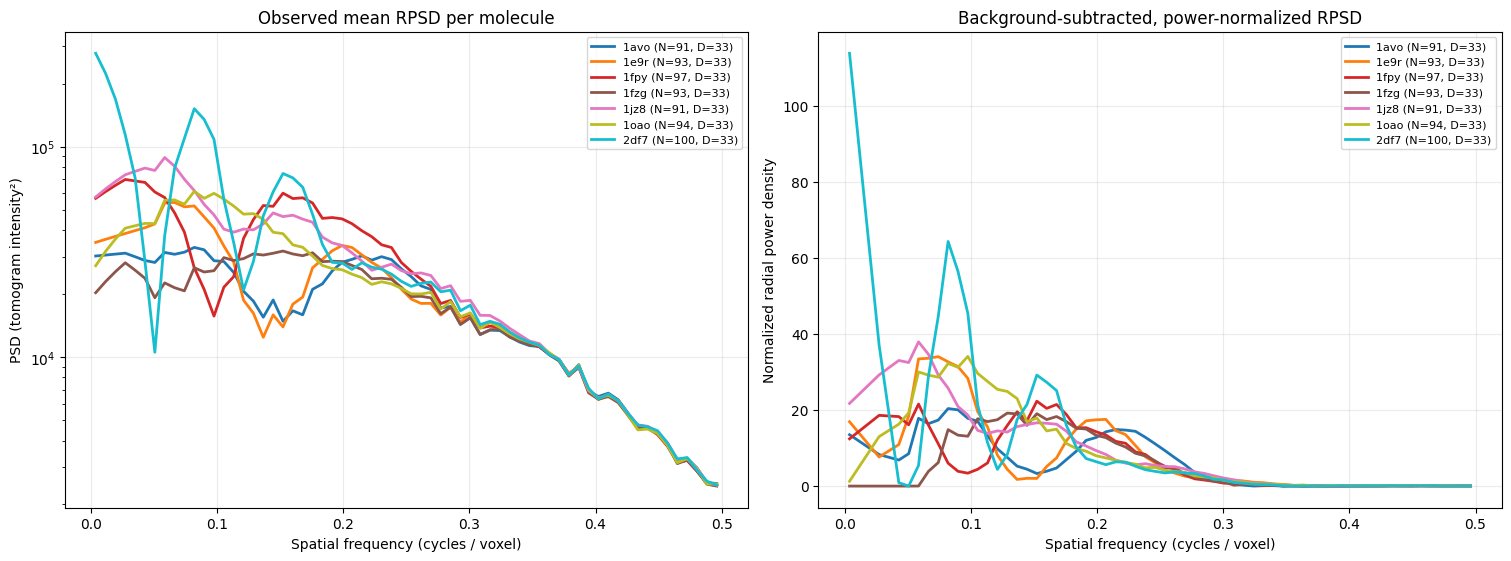

In [6]:
colors = plt.cm.tab10(np.linspace(0, 1, len(results)))
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), constrained_layout=True)

for color, (name, value) in zip(colors, results.items()):
    label = f"{name} (N={len(value['cubes'])}, D={value['diameter']:g})"
    axes[0].plot(radial_frequency, value["observed_mean"], color=color, lw=2, label=label)
    axes[1].plot(radial_frequency, value["signal_shape"], color=color, lw=2, label=label)

axes[0].set_title("Observed mean RPSD per molecule")
axes[0].set_yscale("log")
axes[0].set_ylabel("PSD (tomogram intensity²)")
axes[1].set_title("Background-subtracted, power-normalized RPSD")
axes[1].set_ylabel("Normalized radial power density")
for ax in axes:
    ax.set_xlabel("Spatial frequency (cycles / voxel)")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.show()

## Spectral-shape similarity

The correlation matrix summarizes whether two molecules distribute power similarly over spatial frequency. It is insensitive to the absolute RPSD amplitude shown in the left overlay.

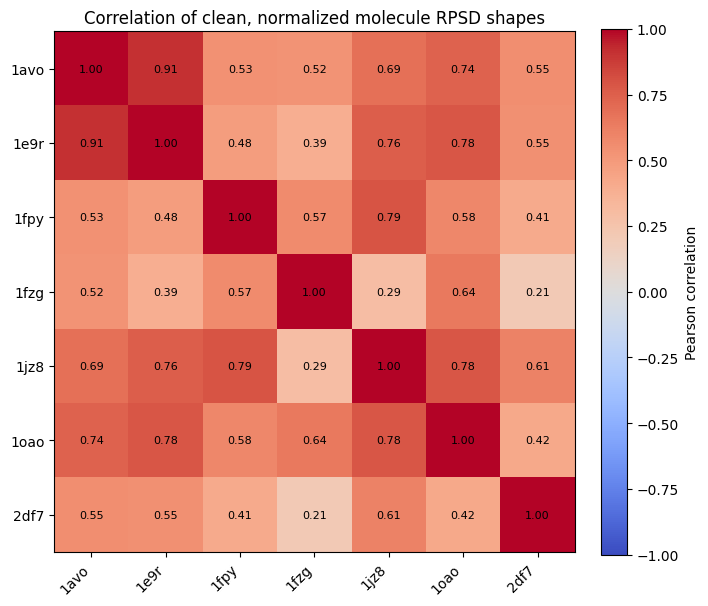

,1avo,1e9r,1fpy,1fzg,1jz8,1oao,2df7
1avo,1.000000,0.910968,0.534576,0.524972,0.686709,0.742061,0.551434
1e9r,0.910968,1.000000,0.483365,0.386623,0.756750,0.782932,0.546444
1fpy,0.534576,0.483365,1.000000,0.566115,0.790570,0.582932,0.410765
1fzg,0.524972,0.386623,0.566115,1.000000,0.294000,0.644095,0.209080
1jz8,0.686709,0.756750,0.790570,0.294000,1.000000,0.782237,0.605097
1oao,0.742061,0.782932,0.582932,0.644095,0.782237,1.000000,0.419055
2df7,0.551434,0.546444,0.410765,0.209080,0.605097,0.419055,1.000000


In [7]:
class_order = list(results)
shape_matrix = np.stack([results[name]["signal_shape"] for name in class_order])
spectral_correlation = np.corrcoef(shape_matrix)

fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)
im = ax.imshow(spectral_correlation, vmin=-1, vmax=1, cmap="coolwarm")
ax.set_xticks(range(len(class_order)), class_order, rotation=45, ha="right")
ax.set_yticks(range(len(class_order)), class_order)
for i in range(len(class_order)):
    for j in range(len(class_order)):
        ax.text(j, i, f"{spectral_correlation[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation of clean, normalized molecule RPSD shapes")
fig.colorbar(im, ax=ax, label="Pearson correlation")
plt.show()

pd.DataFrame(spectral_correlation, index=class_order, columns=class_order)

## Does the unsupervised two-pass KLT RPSD resemble one molecule or their average?

This section repeats the RPSD portion of `tomotwin_2df7.ipynb` with the same ROI and numerical settings. The algorithm receives only the tomogram: **GT labels are not used to fit its RPSD**. After the first ALS pass, its calibrated noise RPSD whitens the band-passed ROI; the second ALS pass produces the recovered post-whitening particle RPSD.

GT is used only afterward to estimate post-whitening class RPSDs from centered 25³ patches. These class curves use the same isotropic autocorrelation estimator and radial grid as the KLT algorithm, followed by subtraction of one common empirical background RPSD from molecule-free patches. All curves are normalized by their 3-D radial power integral so this comparison tests spectral shape rather than arbitrary scale.

In [8]:
KLT_PARTICLE_DIAMETER_VOXELS = 33
KLT_PSD_PATCH_FRACTION = 0.8
# tomotwin_2df7 uses odd_floor.
KLT_PSD_PATCH_SIZE = int(np.floor(KLT_PSD_PATCH_FRACTION * KLT_PARTICLE_DIAMETER_VOXELS))
if KLT_PSD_PATCH_SIZE % 2 == 0:
    KLT_PSD_PATCH_SIZE -= 1
KLT_ROI_START_ZYX = np.array([24, 16, 304])
KLT_ROI_SIZE = 128
KLT_BANDPASS_LOW_FRACTION = 0.05
KLT_BANDPASS_HIGH_FRACTION = 0.05
KLT_ALS_MAX_ITER = 500
KLT_BANDLIMIT = np.pi

klt_roi_stop = KLT_ROI_START_ZYX + KLT_ROI_SIZE
klt_roi_slices = tuple(slice(int(a), int(b)) for a, b in zip(KLT_ROI_START_ZYX, klt_roi_stop))
klt_raw_roi = tomogram[klt_roi_slices].copy()
klt_preprocessed_roi = np.asarray(bandpass_filter_3d(
    klt_raw_roi,
    low_fraction=KLT_BANDPASS_LOW_FRACTION,
    high_fraction=KLT_BANDPASS_HIGH_FRACTION,
    normalize=True,
))

klt_detector = KLTParticleDetector3D(
    tomogram=klt_raw_roi,
    particle_diameter=KLT_PARTICLE_DIAMETER_VOXELS,
    mgscale=1.0,
    num_particles=-1,
    legendre_order=40,
    threshold=0.5,
    max_iter=KLT_ALS_MAX_ITER,
    max_order=4,
    psd_patch_size=KLT_PSD_PATCH_SIZE,
    fredholm_radius=0.5 * KLT_PARTICLE_DIAMETER_VOXELS,
    template_side=35,
    bandpass_low_fraction=KLT_BANDPASS_LOW_FRACTION,
    bandpass_high_fraction=KLT_BANDPASS_HIGH_FRACTION,
)

start = time.perf_counter()
klt_first_particle_psd, klt_first_noise_psd, klt_first_noise_variance = (
    klt_detector.factorize_RPSD(klt_preprocessed_roi)
)
klt_whitened_roi = np.asarray(prewhiten_tomogram(
    jnp.asarray(klt_preprocessed_roi),
    klt_detector.uniform_points,
    klt_first_noise_psd,
))
klt_post_particle_psd, klt_post_noise_psd, klt_post_noise_variance = (
    klt_detector.factorize_RPSD(klt_whitened_roi)
)
jax.block_until_ready(klt_post_particle_psd)
print(f"Two-pass KLT RPSD estimation: {time.perf_counter() - start:.2f} s")
print({
    "ROI start zyx": tuple(KLT_ROI_START_ZYX),
    "ROI size": KLT_ROI_SIZE,
    "particle diameter setting": KLT_PARTICLE_DIAMETER_VOXELS,
    "PSD patch size": KLT_PSD_PATCH_SIZE,
    "radial samples": len(klt_detector.uniform_points),
    "first noise variance": klt_first_noise_variance,
    "post-whitening noise variance": klt_post_noise_variance,
})

Two-pass KLT RPSD estimation: 4.47 s
{'ROI start zyx': (np.int64(24), np.int64(16), np.int64(304)), 'ROI size': 128, 'particle diameter setting': 33, 'PSD patch size': 25, 'radial samples': 25, 'first noise variance': 0.7957611680030823, 'post-whitening noise variance': 3.5161383493687026e-07}


In [9]:
klt_frequency_rad_per_voxel = np.asarray(klt_detector.uniform_points)
klt_frequency_cycles_per_voxel = klt_frequency_rad_per_voxel / (2 * np.pi)
klt_max_distance = int(np.floor(0.3 * KLT_PSD_PATCH_SIZE))
klt_vect_spectrum = jax.vmap(estimate_isotropic_powerspectrum_tensor, in_axes=(0, None))
klt_vect_radial_average = jax.vmap(radial_average_jax, in_axes=(0, None, None, None))

def klt_rpsds_for_cubes(cubes):
    centered = jnp.asarray(np.stack(cubes))
    centered = centered - jnp.mean(centered, axis=(1, 2, 3), keepdims=True)
    psds = klt_vect_spectrum(centered, klt_max_distance)
    radial = klt_vect_radial_average(
        psds,
        klt_detector.shell_ids,
        klt_detector.counts,
        klt_frequency_rad_per_voxel.size,
    )
    return np.asarray(radial)

roi_positions = positions.copy()
roi_positions[["z", "y", "x"]] = (
    roi_positions[["z", "y", "x"]].to_numpy() - KLT_ROI_START_ZYX
)
inside_klt_roi = np.all(
    (roi_positions[["z", "y", "x"]].to_numpy() >= 0)
    & (roi_positions[["z", "y", "x"]].to_numpy() < KLT_ROI_SIZE),
    axis=1,
)
roi_positions = roi_positions.loc[inside_klt_roi].copy()
all_roi_gt_zyx = roi_positions[["z", "y", "x"]].to_numpy(float)

klt_background_centers = sample_background_centers(
    klt_whitened_roi.shape,
    KLT_PSD_PATCH_SIZE,
    n=25,
    forbidden_zyx=all_roi_gt_zyx,
    exclusion_radius=KLT_PSD_PATCH_SIZE,
    rng=np.random.default_rng(RANDOM_SEED + 1),
)
klt_background_cubes, _ = extract_valid_cubes(
    klt_whitened_roi, klt_background_centers, KLT_PSD_PATCH_SIZE
)
klt_empirical_background = klt_rpsds_for_cubes(klt_background_cubes).mean(axis=0)

def normalize_on_klt_grid(curve):
    curve = np.maximum(np.asarray(curve, dtype=float), 0.0)
    weights = 4 * np.pi * klt_frequency_rad_per_voxel**2
    total = np.trapezoid(weights * curve, klt_frequency_rad_per_voxel)
    return curve / total if total > 0 else np.zeros_like(curve)

klt_class_curves = {}
klt_class_counts = {}
for molecule in MOLECULE_CLASSES:
    centers = roi_positions.loc[
        roi_positions["class"] == molecule, ["z", "y", "x"]
    ].to_numpy(float)
    cubes, _ = extract_valid_cubes(klt_whitened_roi, centers, KLT_PSD_PATCH_SIZE)
    if not cubes:
        continue
    observed = klt_rpsds_for_cubes(cubes).mean(axis=0)
    clean = np.maximum(observed - klt_empirical_background, 0.0)
    klt_class_curves[molecule] = normalize_on_klt_grid(clean)
    klt_class_counts[molecule] = len(cubes)

klt_recovered_shape = normalize_on_klt_grid(klt_post_particle_psd)
klt_equal_class_average = np.mean(np.stack(list(klt_class_curves.values())), axis=0)
klt_equal_class_average = normalize_on_klt_grid(klt_equal_class_average)
klt_instance_weighted_average = np.average(
    np.stack(list(klt_class_curves.values())),
    axis=0,
    weights=np.array([klt_class_counts[name] for name in klt_class_curves]),
)
klt_instance_weighted_average = normalize_on_klt_grid(klt_instance_weighted_average)
klt_true_2df7_shape = klt_class_curves["2df7"]

display(pd.Series(klt_class_counts, name="fully contained GT patches").to_frame())

,fully contained GT patches
1avo,7
1e9r,2
1fpy,2
1fzg,6
1jz8,2
1oao,3
2df7,7


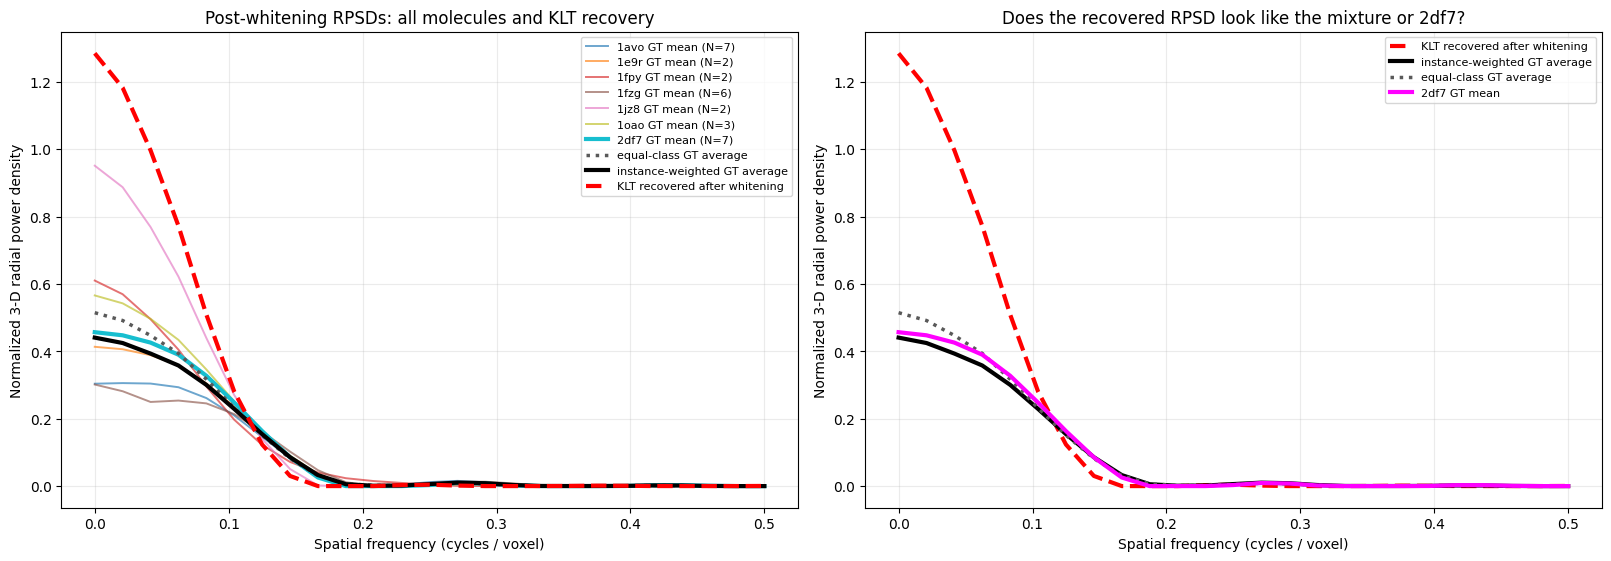

,comparison,cosine similarity,Pearson correlation,RMSE
4,GT 1jz8,0.9982,0.9979,0.1056
2,GT 1fpy,0.9936,0.9935,0.2258
5,GT 1oao,0.9808,0.9775,0.2303
7,equal-class GT average,0.9799,0.9767,0.2498
8,instance-weighted GT average,0.9690,0.9635,0.2738
6,GT 2df7,0.9667,0.9598,0.2636
1,GT 1e9r,0.9609,0.9529,0.2795
0,GT 1avo,0.9397,0.9263,0.317
3,GT 1fzg,0.9241,0.9066,0.328


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5), constrained_layout=True)
comparison_colors = plt.cm.tab10(np.linspace(0, 1, len(klt_class_curves)))

for color, (name, curve) in zip(comparison_colors, klt_class_curves.items()):
    style = "-" if name == "2df7" else "-"
    width = 3.0 if name == "2df7" else 1.4
    alpha = 1.0 if name == "2df7" else 0.65
    axes[0].plot(
        klt_frequency_cycles_per_voxel, curve,
        style, color=color, lw=width, alpha=alpha,
        label=f"{name} GT mean (N={klt_class_counts[name]})",
    )
axes[0].plot(
    klt_frequency_cycles_per_voxel, klt_equal_class_average,
    color="0.35", lw=2.5, ls=":", label="equal-class GT average",
)
axes[0].plot(
    klt_frequency_cycles_per_voxel, klt_instance_weighted_average,
    color="black", lw=3, label="instance-weighted GT average",
)
axes[0].plot(
    klt_frequency_cycles_per_voxel, klt_recovered_shape,
    color="red", lw=3, ls="--", label="KLT recovered after whitening",
)
axes[0].set_title("Post-whitening RPSDs: all molecules and KLT recovery")

axes[1].plot(
    klt_frequency_cycles_per_voxel, klt_recovered_shape,
    color="red", lw=3, ls="--", label="KLT recovered after whitening",
)
axes[1].plot(
    klt_frequency_cycles_per_voxel, klt_instance_weighted_average,
    color="black", lw=3, label="instance-weighted GT average",
)
axes[1].plot(
    klt_frequency_cycles_per_voxel, klt_equal_class_average,
    color="0.35", lw=2.5, ls=":", label="equal-class GT average",
)
axes[1].plot(
    klt_frequency_cycles_per_voxel, klt_true_2df7_shape,
    color="magenta", lw=3, label="2df7 GT mean",
)
axes[1].set_title("Does the recovered RPSD look like the mixture or 2df7?")

for ax in axes:
    ax.set_xlabel("Spatial frequency (cycles / voxel)")
    ax.set_ylabel("Normalized 3-D radial power density")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)
plt.show()

def cosine_similarity(a, b):
    a, b = np.asarray(a), np.asarray(b)
    denominator = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / denominator) if denominator > 0 else np.nan

comparison_curves = {
    **{f"GT {name}": curve for name, curve in klt_class_curves.items()},
    "equal-class GT average": klt_equal_class_average,
    "instance-weighted GT average": klt_instance_weighted_average,
}
klt_similarity = pd.DataFrame([
    {
        "comparison": name,
        "cosine similarity": cosine_similarity(klt_recovered_shape, curve),
        "Pearson correlation": np.corrcoef(klt_recovered_shape, curve)[0, 1],
        "RMSE": np.sqrt(np.mean((klt_recovered_shape - curve)**2)),
    }
    for name, curve in comparison_curves.items()
]).sort_values("cosine similarity", ascending=False)
display(klt_similarity.style.format({
    "cosine similarity": "{:.4f}",
    "Pearson correlation": "{:.4f}",
    "RMSE": "{:.4g}",
}))

## Matched 33³ KLT experiment: sweep the ACF support

The exact-pipeline result above uses a 128³ ROI, 25³ PSD patches and `max_distance=7`. Here the ROI keeps the same start but expands to 160³ so all seven classes have fully contained 33³ references and ALS receives 64 rather than 27 non-overlapping patches. The entire two-pass procedure is repeated for `max_distance ∈ {7, 10, 12, 16, 24}`. For every value, ALS patches and GT-centered molecule patches use the **same KLT isotropic-autocorrelation estimator**, radial grid, band-pass and whitened ROI.

The main figure contains one panel per ACF support. Each panel shows all molecule RPSDs, highlights 2DF7, and overlays the recovered KLT particle RPSD and pooled GT mixture.

In [11]:
SWEEP_PATCH_SIZE = 33
SWEEP_ROI_START_ZYX = KLT_ROI_START_ZYX.copy()
SWEEP_ROI_SIZE = 160
SWEEP_MAX_DISTANCES = [7, 10, 12, 16, 24]

sweep_roi_stop = SWEEP_ROI_START_ZYX + SWEEP_ROI_SIZE
sweep_roi_slices = tuple(
    slice(int(start), int(stop))
    for start, stop in zip(SWEEP_ROI_START_ZYX, sweep_roi_stop)
)
sweep_raw_roi = tomogram[sweep_roi_slices].copy()
sweep_preprocessed_roi = np.asarray(bandpass_filter_3d(
    sweep_raw_roi,
    low_fraction=KLT_BANDPASS_LOW_FRACTION,
    high_fraction=KLT_BANDPASS_HIGH_FRACTION,
    normalize=True,
))

sweep_roi_positions = positions.copy()
sweep_roi_positions[["z", "y", "x"]] = (
    sweep_roi_positions[["z", "y", "x"]].to_numpy() - SWEEP_ROI_START_ZYX
)
inside_sweep_roi = np.all(
    (sweep_roi_positions[["z", "y", "x"]].to_numpy() >= 0)
    & (sweep_roi_positions[["z", "y", "x"]].to_numpy() < SWEEP_ROI_SIZE),
    axis=1,
)
sweep_roi_positions = sweep_roi_positions.loc[inside_sweep_roi].copy()

sweep_detector = KLTParticleDetector3D(
    tomogram=sweep_raw_roi,
    particle_diameter=KLT_PARTICLE_DIAMETER_VOXELS,
    mgscale=1.0,
    num_particles=-1,
    legendre_order=40,
    threshold=0.5,
    max_iter=KLT_ALS_MAX_ITER,
    max_order=4,
    psd_patch_size=SWEEP_PATCH_SIZE,
    fredholm_radius=0.5 * KLT_PARTICLE_DIAMETER_VOXELS,
    template_side=35,
    bandpass_low_fraction=KLT_BANDPASS_LOW_FRACTION,
    bandpass_high_fraction=KLT_BANDPASS_HIGH_FRACTION,
)
sweep_omega = np.asarray(sweep_detector.uniform_points)
sweep_cycles = sweep_omega / (2 * np.pi)

def extract_nonoverlapping_sweep_patches(volume, side=SWEEP_PATCH_SIZE):
    blocks = np.asarray(volume.shape) // side
    cropped_shape = blocks * side
    cropped = volume[tuple(slice(0, int(stop)) for stop in cropped_shape)]
    bz, by, bx = (int(value) for value in blocks)
    patches = cropped.reshape(
        bz, side, by, side, bx, side
    ).transpose(0, 2, 4, 1, 3, 5)
    return patches.reshape(-1, side, side, side), blocks

def sweep_rpsds_for_cubes(cubes, max_distance):
    centered = jnp.asarray(np.stack(cubes))
    centered = centered - jnp.mean(centered, axis=(1, 2, 3), keepdims=True)
    psds = klt_vect_spectrum(centered, max_distance)
    radial = klt_vect_radial_average(
        psds,
        sweep_detector.shell_ids,
        sweep_detector.counts,
        sweep_omega.size,
    )
    return np.asarray(radial)

def factorize_with_max_distance(volume, max_distance):
    patches, blocks = extract_nonoverlapping_sweep_patches(volume)
    centered = jnp.asarray(patches)
    centered = centered - jnp.mean(centered, axis=(1, 2, 3), keepdims=True)
    variances = np.asarray(jnp.var(centered, axis=(1, 2, 3)))
    noise_count = max(1, int(np.floor(0.25 * len(variances))))
    noise_variance = float(np.mean(np.sort(variances)[:noise_count]))
    mean_variance = float(np.mean(variances))
    rblocks = sweep_rpsds_for_cubes(np.asarray(centered), max_distance)
    factorization = alternating_least_squares_solver(
        jnp.asarray(rblocks), KLT_ALS_MAX_ITER, 1e-4
    )
    particle_psd, noise_psd = calibrate_radial_psds(
        sweep_omega,
        factorization.gamma,
        factorization.v,
        noise_variance,
        mean_variance,
    )
    return {
        "blocks": blocks,
        "patch_count": len(patches),
        "particle_psd": np.asarray(particle_psd),
        "noise_psd": np.asarray(noise_psd),
        "noise_variance": noise_variance,
        "mean_variance": mean_variance,
        "factorization": factorization,
    }

def normalize_on_sweep_grid(curve):
    curve = np.maximum(np.asarray(curve, dtype=float), 0.0)
    weights = 4 * np.pi * sweep_omega**2
    total = np.trapezoid(weights * curve, sweep_omega)
    return curve / total if total > 0 else np.zeros_like(curve)

sweep_patch_blocks = np.asarray(sweep_preprocessed_roi.shape) // SWEEP_PATCH_SIZE
print({
    "ROI start zyx": tuple(SWEEP_ROI_START_ZYX),
    "ROI size": SWEEP_ROI_SIZE,
    "patch size": SWEEP_PATCH_SIZE,
    "non-overlapping blocks": tuple(sweep_patch_blocks),
    "patches per ALS pass": int(np.prod(sweep_patch_blocks)),
    "max distances": SWEEP_MAX_DISTANCES,
})

{'ROI start zyx': (np.int64(24), np.int64(16), np.int64(304)), 'ROI size': 160, 'patch size': 33, 'non-overlapping blocks': (np.int64(4), np.int64(4), np.int64(4)), 'patches per ALS pass': 64, 'max distances': [7, 10, 12, 16, 24]}


In [12]:
sweep_results = {}
sweep_start = time.perf_counter()

for max_distance in SWEEP_MAX_DISTANCES:
    run_start = time.perf_counter()
    first_pass = factorize_with_max_distance(sweep_preprocessed_roi, max_distance)
    whitened_roi = np.asarray(prewhiten_tomogram(
        jnp.asarray(sweep_preprocessed_roi),
        sweep_omega,
        first_pass["noise_psd"],
    ))
    second_pass = factorize_with_max_distance(whitened_roi, max_distance)

    class_clean = {}
    class_shapes = {}
    class_counts = {}
    all_instance_rpsds = []
    for molecule in MOLECULE_CLASSES:
        centers = sweep_roi_positions.loc[
            sweep_roi_positions["class"] == molecule, ["z", "y", "x"]
        ].to_numpy(float)
        cubes, _ = extract_valid_cubes(whitened_roi, centers, SWEEP_PATCH_SIZE)
        if not cubes:
            continue
        instance_rpsds = sweep_rpsds_for_cubes(cubes, max_distance)
        observed = instance_rpsds.mean(axis=0)
        clean = np.maximum(observed - second_pass["noise_psd"], 0.0)
        class_clean[molecule] = clean
        class_shapes[molecule] = normalize_on_sweep_grid(clean)
        class_counts[molecule] = len(cubes)
        all_instance_rpsds.append(instance_rpsds)

    pooled_observed = np.concatenate(all_instance_rpsds, axis=0).mean(axis=0)
    pooled_clean = np.maximum(pooled_observed - second_pass["noise_psd"], 0.0)
    pooled_shape = normalize_on_sweep_grid(pooled_clean)
    equal_class_shape = normalize_on_sweep_grid(
        np.mean(np.stack(list(class_shapes.values())), axis=0)
    )
    equal_class_clean = np.mean(np.stack(list(class_clean.values())), axis=0)
    recovered_shape = normalize_on_sweep_grid(second_pass["particle_psd"])

    sweep_results[max_distance] = {
        "first": first_pass,
        "second": second_pass,
        "class_clean": class_clean,
        "class_shapes": class_shapes,
        "class_counts": class_counts,
        "pooled_clean": pooled_clean,
        "pooled_shape": pooled_shape,
        "equal_class_clean": equal_class_clean,
        "equal_class_shape": equal_class_shape,
        "recovered_psd": np.asarray(second_pass["particle_psd"]),
        "recovered_shape": recovered_shape,
        "elapsed": time.perf_counter() - run_start,
    }
    print(
        f"max_distance={max_distance:2d}: "
        f"{sweep_results[max_distance]['elapsed']:.2f} s, "
        f"GT counts={class_counts}"
    )

print(f"Total ACF-support sweep: {time.perf_counter() - sweep_start:.2f} s")

max_distance= 7: 14.24 s, GT counts={'1avo': 8, '1e9r': 7, '1fpy': 3, '1fzg': 11, '1jz8': 5, '1oao': 6, '2df7': 11}


max_distance=10: 6.01 s, GT counts={'1avo': 8, '1e9r': 7, '1fpy': 3, '1fzg': 11, '1jz8': 5, '1oao': 6, '2df7': 11}


max_distance=12: 5.88 s, GT counts={'1avo': 8, '1e9r': 7, '1fpy': 3, '1fzg': 11, '1jz8': 5, '1oao': 6, '2df7': 11}


max_distance=16: 6.28 s, GT counts={'1avo': 8, '1e9r': 7, '1fpy': 3, '1fzg': 11, '1jz8': 5, '1oao': 6, '2df7': 11}


max_distance=24: 6.69 s, GT counts={'1avo': 8, '1e9r': 7, '1fpy': 3, '1fzg': 11, '1jz8': 5, '1oao': 6, '2df7': 11}
Total ACF-support sweep: 39.11 s


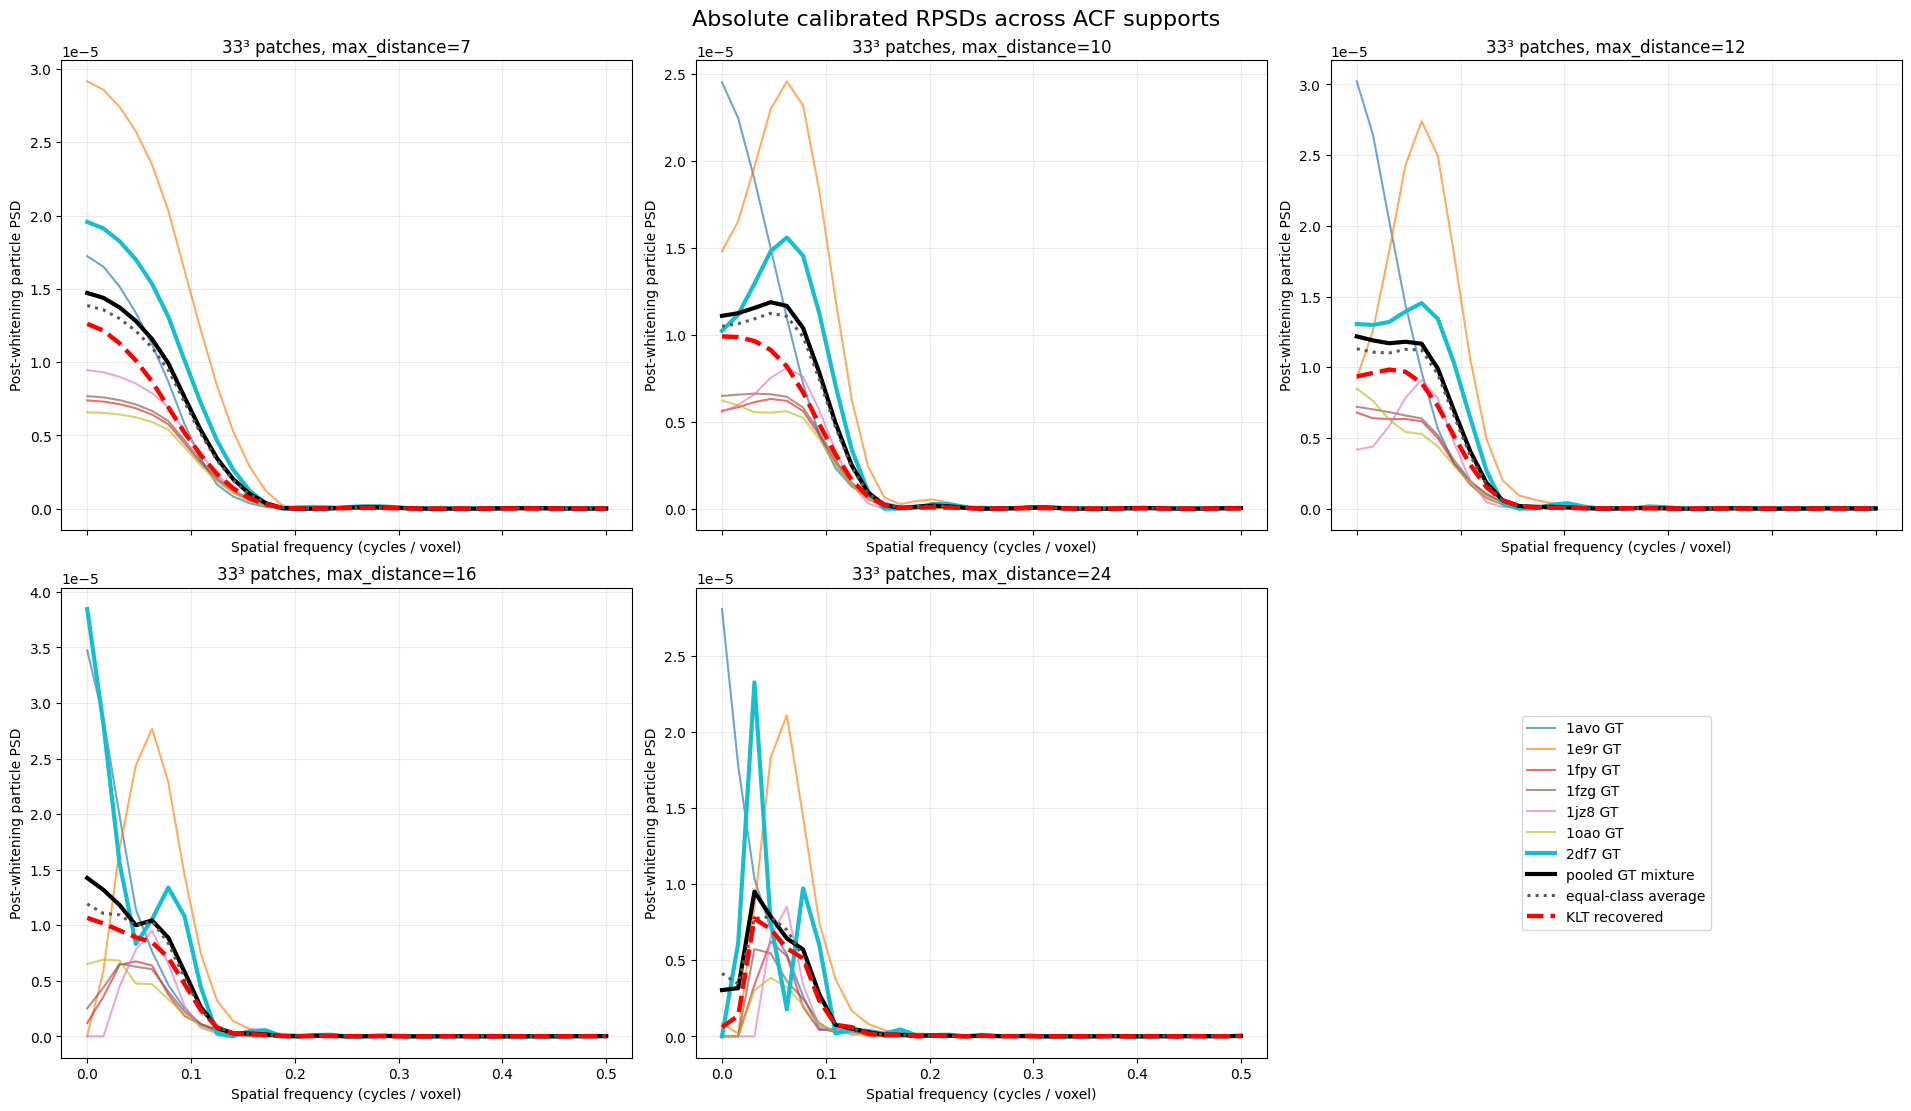

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11), sharex=True, constrained_layout=True)
axes = axes.ravel()
molecule_colors = dict(zip(
    MOLECULE_CLASSES, plt.cm.tab10(np.linspace(0, 1, len(MOLECULE_CLASSES)))
))

for ax, max_distance in zip(axes, SWEEP_MAX_DISTANCES):
    run = sweep_results[max_distance]
    for molecule in MOLECULE_CLASSES:
        if molecule not in run["class_clean"]:
            continue
        is_target = molecule == "2df7"
        ax.plot(
            sweep_cycles,
            run["class_clean"][molecule],
            color=molecule_colors[molecule],
            lw=3.0 if is_target else 1.5,
            alpha=1.0 if is_target else 0.65,
            label="2df7 GT" if is_target else f"{molecule} GT",
        )
    ax.plot(
        sweep_cycles, run["pooled_clean"],
        color="black", lw=3, label="pooled GT mixture",
    )
    ax.plot(
        sweep_cycles, run["equal_class_clean"],
        color="0.35", lw=2.2, ls=":", label="equal-class average",
    )
    ax.plot(
        sweep_cycles, run["recovered_psd"],
        color="red", lw=3.2, ls="--", label="KLT recovered",
    )
    ax.set_title(f"33³ patches, max_distance={max_distance}")
    ax.set_xlabel("Spatial frequency (cycles / voxel)")
    ax.set_ylabel("Post-whitening particle PSD")
    ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
    ax.grid(alpha=0.25)

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[-1].legend(by_label.values(), by_label.keys(), loc="center", fontsize=10)
fig.suptitle("Absolute calibrated RPSDs across ACF supports", fontsize=16)
plt.show()

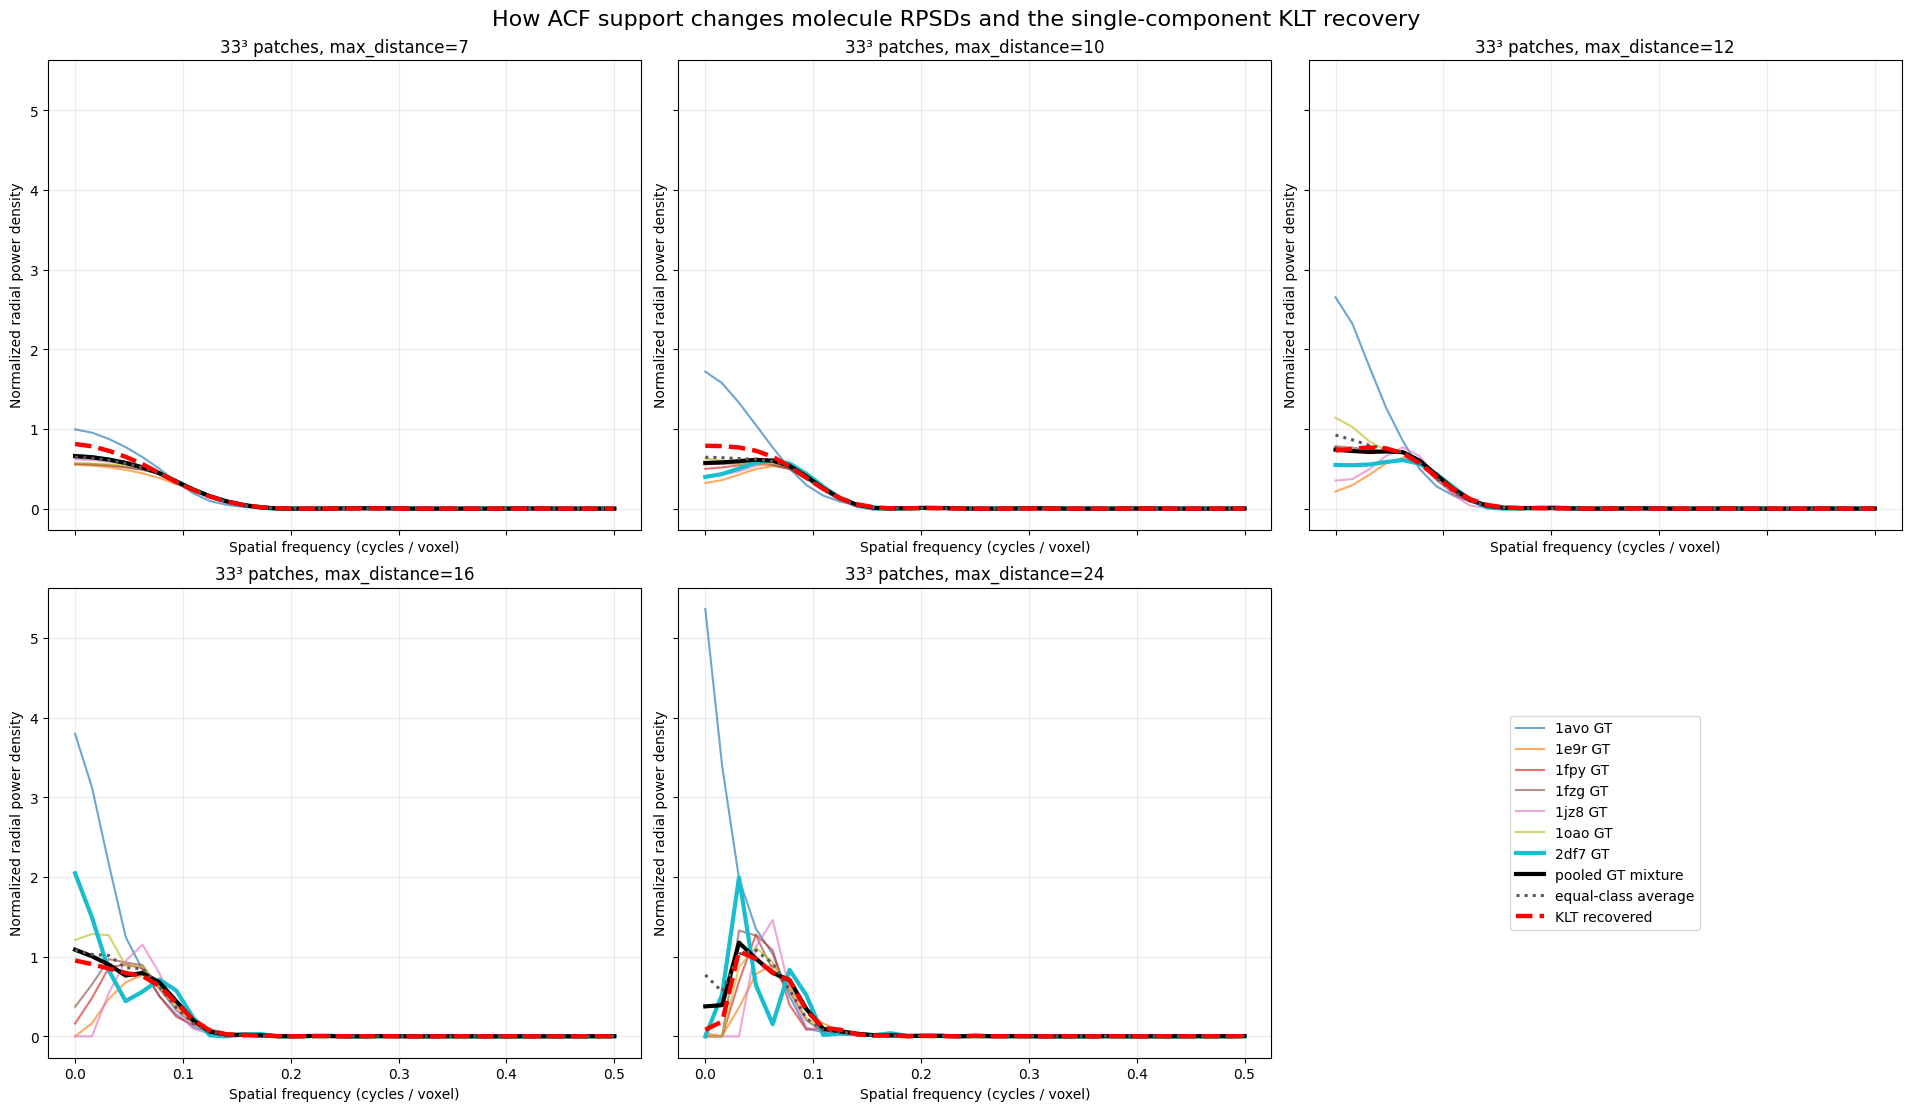

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(19, 11), sharex=True, sharey=True, constrained_layout=True)
axes = axes.ravel()
molecule_colors = dict(zip(
    MOLECULE_CLASSES, plt.cm.tab10(np.linspace(0, 1, len(MOLECULE_CLASSES)))
))

for ax, max_distance in zip(axes, SWEEP_MAX_DISTANCES):
    run = sweep_results[max_distance]
    for molecule in MOLECULE_CLASSES:
        if molecule not in run["class_shapes"]:
            continue
        is_target = molecule == "2df7"
        ax.plot(
            sweep_cycles,
            run["class_shapes"][molecule],
            color=molecule_colors[molecule],
            lw=3.0 if is_target else 1.5,
            alpha=1.0 if is_target else 0.65,
            label="2df7 GT" if is_target else f"{molecule} GT",
        )
    ax.plot(
        sweep_cycles, run["pooled_shape"],
        color="black", lw=3, label="pooled GT mixture",
    )
    ax.plot(
        sweep_cycles, run["equal_class_shape"],
        color="0.35", lw=2.2, ls=":", label="equal-class average",
    )
    ax.plot(
        sweep_cycles, run["recovered_shape"],
        color="red", lw=3.2, ls="--", label="KLT recovered",
    )
    ax.set_title(f"33³ patches, max_distance={max_distance}")
    ax.set_xlabel("Spatial frequency (cycles / voxel)")
    ax.set_ylabel("Normalized radial power density")
    ax.grid(alpha=0.25)

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
axes[-1].legend(by_label.values(), by_label.keys(), loc="center", fontsize=10)
fig.suptitle(
    "How ACF support changes molecule RPSDs and the single-component KLT recovery",
    fontsize=16,
)
plt.show()

max_distance,7,10,12,16,24
comparison,,,,,
GT 1avo,0.9968,0.9614,0.9067,0.8937,0.4526
GT 1e9r,0.9942,0.9519,0.9261,0.7998,0.9188
GT 1fpy,0.9917,0.9898,0.9985,0.8943,0.9250
GT 1fzg,0.9913,0.9939,0.9989,0.9445,0.9792
GT 1jz8,0.9945,0.9668,0.9479,0.7355,0.7613
GT 1oao,0.9890,0.9934,0.9836,0.9891,0.9788
GT 2df7,0.9972,0.9627,0.9903,0.9151,0.8539
equal-class average,0.9967,0.9976,0.9953,0.9972,0.9218
pooled GT mixture,0.9972,0.9921,0.9989,0.9985,0.9831


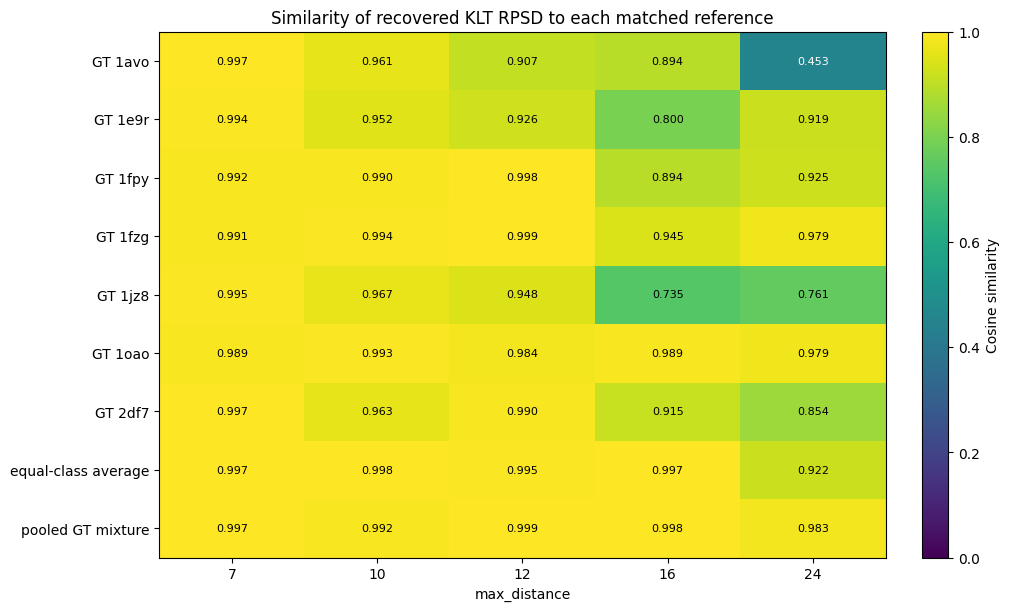

In [15]:
sweep_similarity_rows = []
for max_distance, run in sweep_results.items():
    comparisons = {
        **{f"GT {name}": curve for name, curve in run["class_shapes"].items()},
        "pooled GT mixture": run["pooled_shape"],
        "equal-class average": run["equal_class_shape"],
    }
    for name, curve in comparisons.items():
        sweep_similarity_rows.append({
            "max_distance": max_distance,
            "comparison": name,
            "cosine similarity": cosine_similarity(run["recovered_shape"], curve),
            "Pearson correlation": np.corrcoef(run["recovered_shape"], curve)[0, 1],
            "RMSE": np.sqrt(np.mean((run["recovered_shape"] - curve)**2)),
        })

sweep_similarity = pd.DataFrame(sweep_similarity_rows)
similarity_pivot = sweep_similarity.pivot(
    index="comparison", columns="max_distance", values="cosine similarity"
)
display(similarity_pivot.style.format("{:.4f}"))

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)
image = ax.imshow(similarity_pivot, vmin=0, vmax=1, cmap="viridis", aspect="auto")
ax.set_xticks(range(len(similarity_pivot.columns)), similarity_pivot.columns)
ax.set_yticks(range(len(similarity_pivot.index)), similarity_pivot.index)
ax.set_xlabel("max_distance")
ax.set_title("Similarity of recovered KLT RPSD to each matched reference")
for row in range(similarity_pivot.shape[0]):
    for col in range(similarity_pivot.shape[1]):
        value = similarity_pivot.iloc[row, col]
        text_color = "white" if value < 0.65 else "black"
        ax.text(col, row, f"{value:.3f}", ha="center", va="center", color=text_color, fontsize=8)
fig.colorbar(image, ax=ax, label="Cosine similarity")
plt.show()